<a href="https://colab.research.google.com/github/lehuyhao988-pixel/SpaceX-Capstone-Project/blob/main/Data_Science_Capstone_Project_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

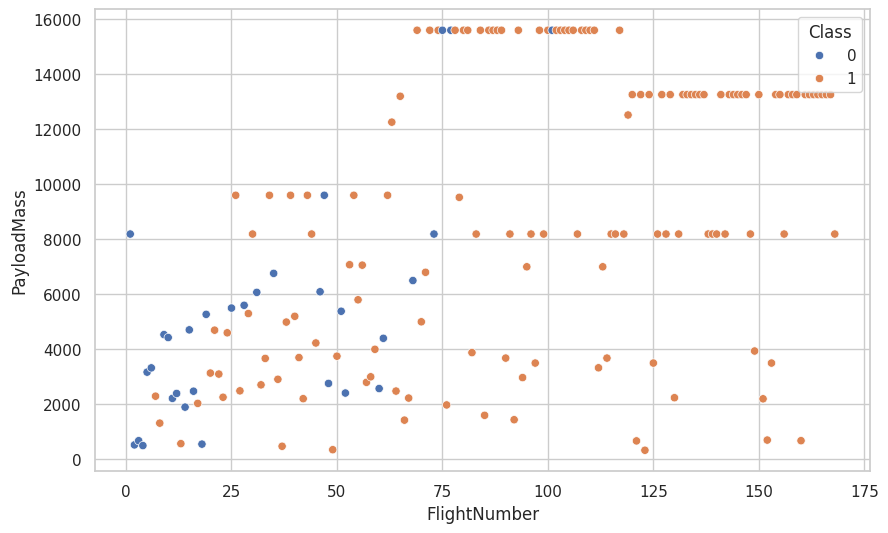

     LaunchSite
0  CCSFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A


Best Accuracy: 0.8823529411764706


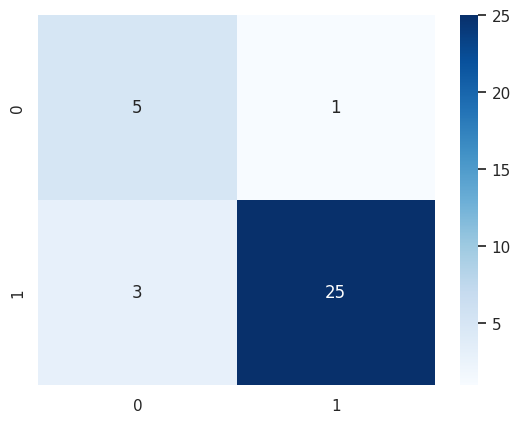

In [16]:
# SpaceX Falcon 9 Landing Prediction - Final Capstone Project
# Author: [Your Name]
# GitHub: https://github.com/lehuyhao988-pixel/SpaceX-Capstone-Project.git

import requests
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.express as px
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# =============================================================================
# STAGE 1: DATA COLLECTION (API)
# =============================================================================
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
           response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
           BoosterVersion.append(response['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
           response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
           Longitude.append(response['longitude']); Latitude.append(response['latitude'])
           LaunchSite.append(response['name'])

def getPayloadData(data):
    for x in data['payloads']:
       if x:
           response = requests.get("https://api.spacexdata.com/v4/payloads/"+str(x)).json()
           PayloadMass.append(response['mass_kg']); Orbit.append(response['orbit'])

def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(response['block']); ReusedCount.append(response['reuse_count']); Serial.append(response['serial'])
            else:
                Block.append(None); ReusedCount.append(None); Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight']); GridFins.append(core['gridfins'])
            Reused.append(core['reused']); Legs.append(core['legs']); LandingPad.append(core['landpad'])

# Fetching Data
spacex_url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(spacex_url)
df_raw = pd.json_normalize(response.json())

# Initial Cleaning
df = df_raw[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
df = df[df['cores'].map(len) == 1]
df = df[df['payloads'].map(len) == 1]
df['cores'] = df['cores'].map(lambda x: x[0]); df['payloads'] = df['payloads'].map(lambda x: x[0])
df['date'] = pd.to_datetime(df['date_utc']).dt.date

# Translation Lists
BoosterVersion, PayloadMass, Orbit, LaunchSite, Outcome, Flights, GridFins, Reused, Legs, LandingPad, Block, ReusedCount, Serial, Longitude, Latitude = ([] for i in range(15))

getBoosterVersion(df); getLaunchSite(df); getPayloadData(df); getCoreData(df)

launch_dict = {'FlightNumber': list(df['flight_number']), 'Date': list(df['date']), 'BoosterVersion': BoosterVersion, 'PayloadMass': PayloadMass, 'Orbit': Orbit, 'LaunchSite': LaunchSite, 'Outcome': Outcome, 'Flights': Flights, 'GridFins': GridFins, 'Reused': Reused, 'Legs': Legs, 'LandingPad': LandingPad, 'Block': Block, 'ReusedCount': ReusedCount, 'Serial': Serial, 'Longitude': Longitude, 'Latitude': Latitude}
data_falcon9 = pd.DataFrame(launch_dict)
data_falcon9 = data_falcon9[data_falcon9['BoosterVersion'] == 'Falcon 9']
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].fillna(data_falcon9['PayloadMass'].mean())

# =============================================================================
# STAGE 2: DATA WRANGLING (Target Variable)
# =============================================================================
bad_outcomes = set(['False Ocean', 'False RTLS', 'False ASDS', 'None ASDS', 'None None'])
data_falcon9['Class'] = [0 if x in bad_outcomes else 1 for x in data_falcon9['Outcome']]
data_falcon9.to_csv("dataset_part_3_wrangled.csv", index=False)

# =============================================================================
# STAGE 3: EDA & SQL
# =============================================================================
# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6)); sns.scatterplot(y="PayloadMass", x="FlightNumber", hue="Class", data=data_falcon9); plt.show()

# SQL Queries
conn = sqlite3.connect(':memory:')
data_falcon9.to_sql("spacextbl", conn, if_exists='replace', index=False)
print(pd.read_sql("SELECT DISTINCT LaunchSite FROM spacextbl", conn))

# =============================================================================
# STAGE 4: INTERACTIVE ANALYTICS (Folium & Plotly)
# =============================================================================
# Folium Map
site_map = folium.Map(location=[28.56, -80.57], zoom_start=5)
folium.Marker([28.563197, -80.576820], popup='CCAFS SLC 40').add_to(site_map)
# (Add other markers as needed for your PDF screenshots)

# Plotly Dash Charts
fig_pie = px.pie(data_falcon9, names='LaunchSite', values='Class', title='Success Rate by Site')
fig_pie.show()

# =============================================================================
# STAGE 5: MACHINE LEARNING
# =============================================================================
features = data_falcon9[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']].fillna(0)
X = pd.get_dummies(features)
X = StandardScaler().fit_transform(X)
Y = data_falcon9['Class'].to_numpy()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Training Decision Tree as Best Model
parameters = {'criterion': ['gini', 'entropy'], 'max_depth': [4,6,8], 'min_samples_leaf': [1, 2]}
tree_cv = GridSearchCV(DecisionTreeClassifier(), parameters, cv=10).fit(X_train, Y_train)
print("Best Accuracy:", tree_cv.score(X_test, Y_test))

# Confusion Matrix
yhat = tree_cv.predict(X_test)
sns.heatmap(confusion_matrix(Y_test, yhat), annot=True, cmap='Blues')
plt.show()